In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
#Load Dataset
df=pd.read_csv("loan/train.csv")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

  Customer ID               Name Gender  Age  Income (USD) Income Stability  \
0     C-36995   Frederica Shealy      F   56       1933.05              Low   
1     C-33999  America Calderone      M   32       4952.91              Low   
2      C-3770      Rosetta Verne      F   65        988.19             High   
3     C-26480         Zoe Chitty      F   65           NaN             High   
4     C-23459       Afton Venema      F   31       2614.77              Low   

  Profession     Type of Employment    Location  Loan Amount Request (USD)  \
0    Working            Sales staff  Semi-Urban                   72809.58   
1    Working                    NaN  Semi-Urban                   46837.47   
2  Pensioner                    NaN  Semi-Urban                   45593.04   
3  Pensioner                    NaN       Rural                   80057.92   
4    Working  High skill tech staff  Semi-Urban                  113858.89   

   ...  Credit Score No. of Defaults Has Active Credit C

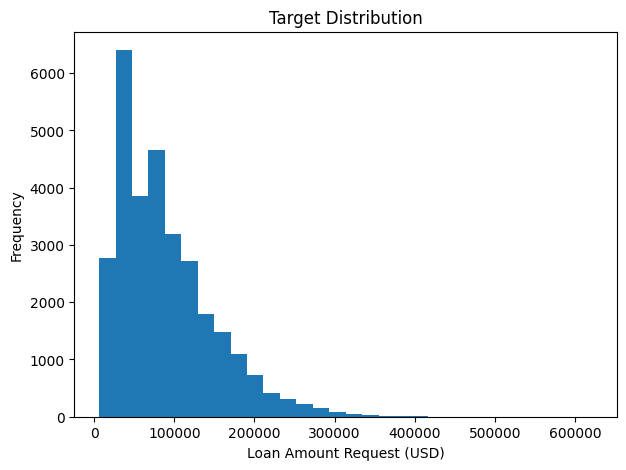

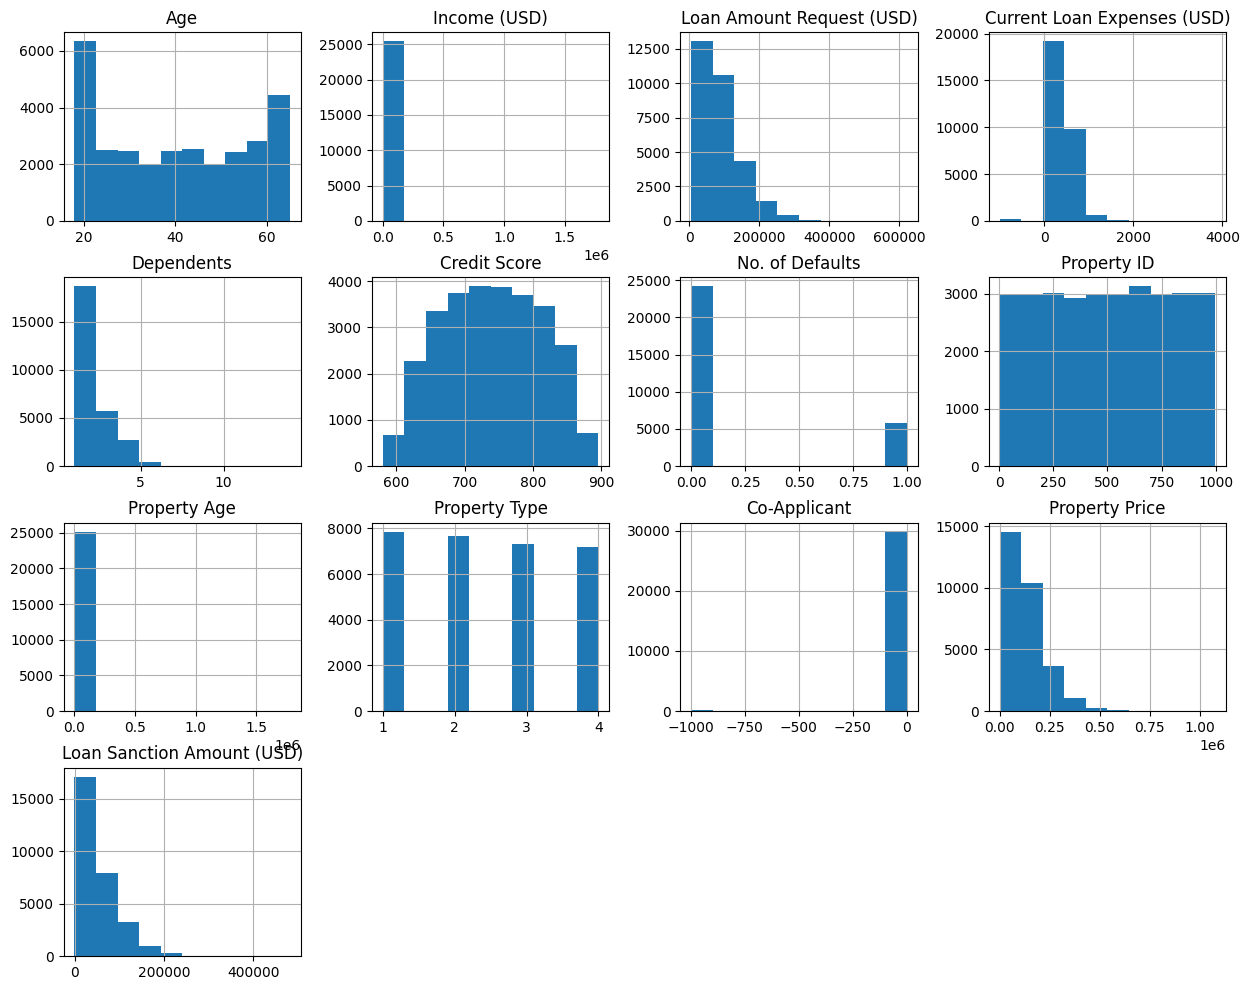

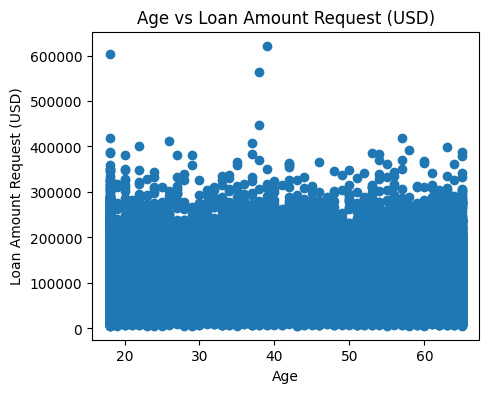

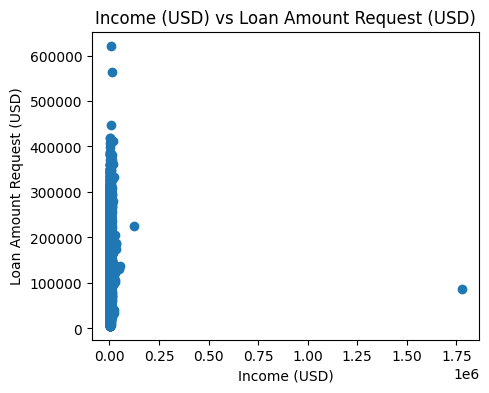

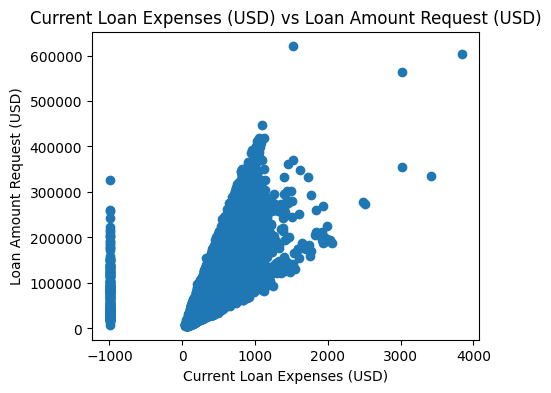

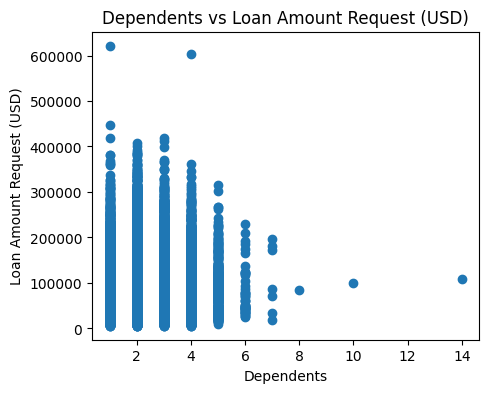

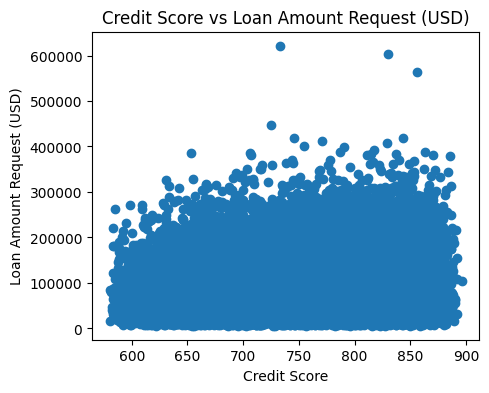

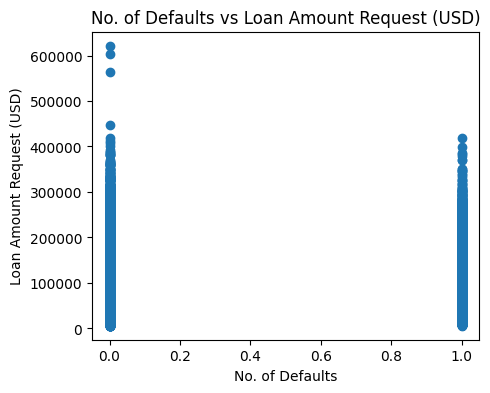

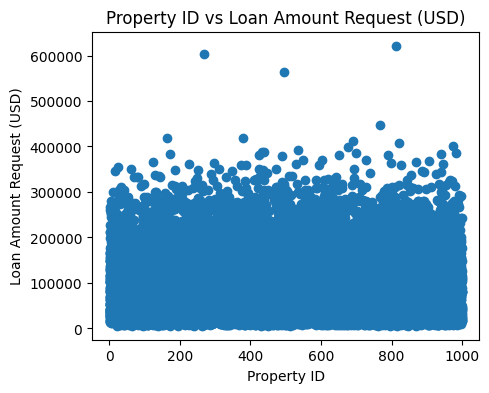

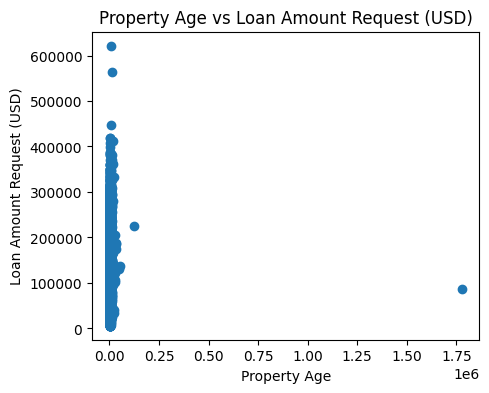

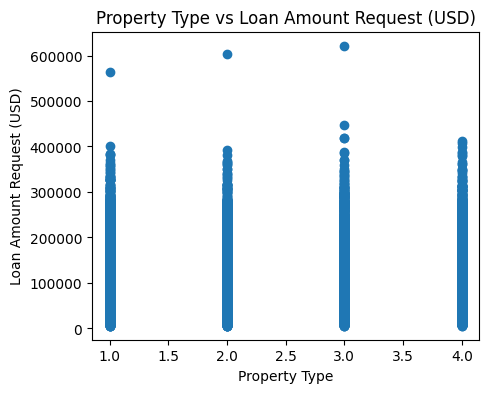

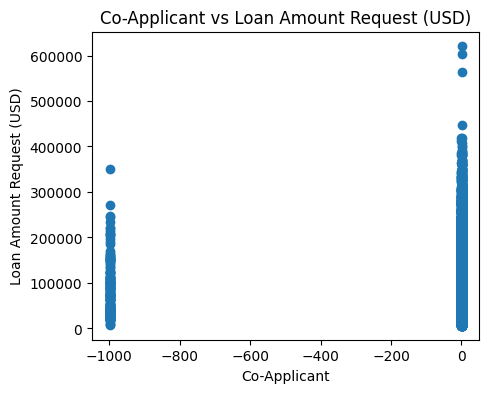

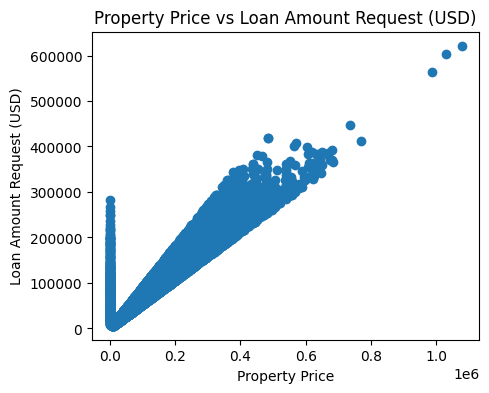

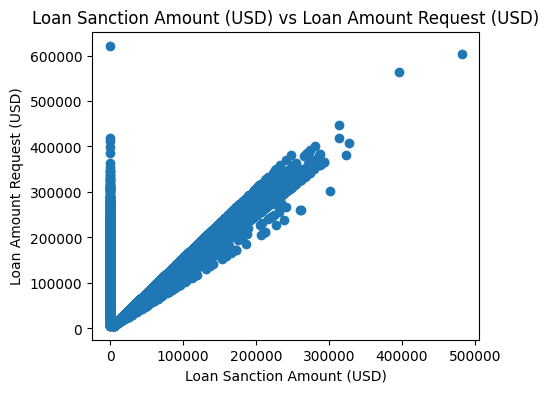

In [26]:
# Target Variable Distribution
target="Loan Amount Request (USD)"

plt.figure(figsize=(7,5))
plt.hist(df[target],bins=30)
plt.title("Target Distribution")
plt.xlabel(target)
plt.ylabel("Frequency")
plt.show()

# Remove Identifier Columns
df=df.drop(columns=["Customer ID","Name"])

# Numerical Feature Distributions
num_cols=df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,12))
plt.show()

# Feature vs Target Scatter Plots
for col in num_cols:
    if col!=target:
        plt.figure(figsize=(5,4))
        plt.scatter(df[col],df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")
        plt.show()

# Split Features and Target
X=df.drop(target,axis=1)
y=df[target]

# Identify Numerical and Categorical Columns
categorical_cols=X.select_dtypes(include="object").columns
numerical_cols=X.select_dtypes(exclude="object").columns

In [27]:
# Data Preprocessing Pipeline
numeric_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor=ColumnTransformer([
    ("num",numeric_transformer,numerical_cols),
    ("cat",categorical_transformer,categorical_cols)
])

In [28]:
#Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Model Evaluation Function
results=[]
def evaluate_model(name,model):
    pipeline=Pipeline([("preprocessor",preprocessor),("model",model)])
    start=time.time()
    pipeline.fit(X_train,y_train)
    training_time=time.time()-start
    y_pred_train=pipeline.predict(X_train)
    y_pred_test=pipeline.predict(X_test)
    mae=mean_absolute_error(y_test,y_pred_test)
    mse=mean_squared_error(y_test,y_pred_test)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,y_pred_test)
    results.append([name,mae,mse,rmse,r2,training_time])
    return pipeline,y_pred_train,y_pred_test

# Train Linear Regression Model
linear_model,linear_train_pred,linear_test_pred=evaluate_model("Linear Regression",LinearRegression())
print(results)

[['Linear Regression', 11418.137616671771, 343529953.811292, np.float64(18534.56106335653), 0.9017190209963786, 0.2348766326904297]]


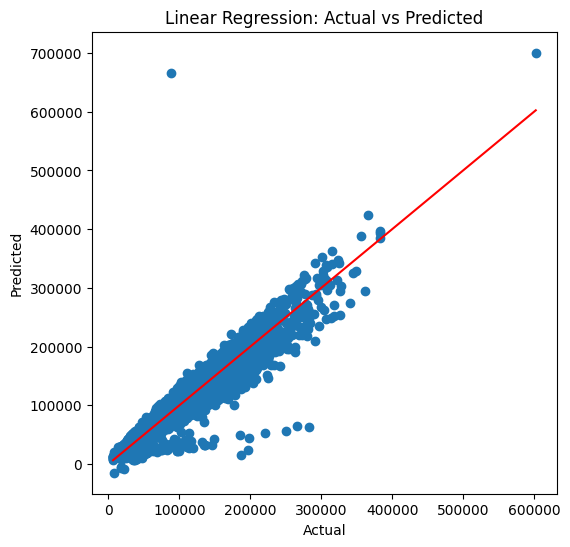

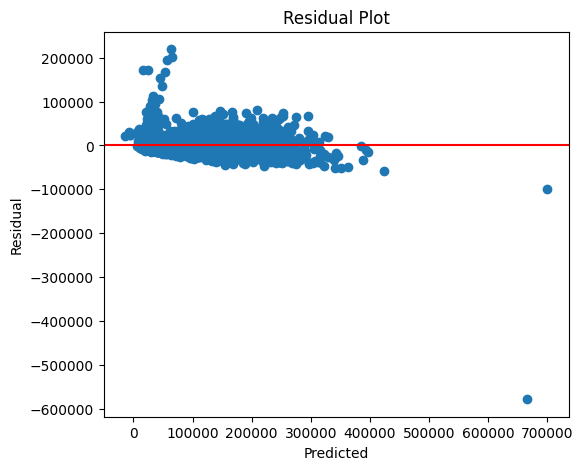

In [29]:
#Predicted vs Actual Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test,linear_test_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# Residual Plot
residuals=y_test-linear_test_pred
plt.figure(figsize=(6,5))
plt.scatter(linear_test_pred,residuals)
plt.axhline(y=0,color='r')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [30]:
#Ridge Regression
ridge_pipeline=Pipeline([("preprocessor",preprocessor),("model",Ridge())])
ridge_params={"model__alpha":[0.01,0.1,1,10,100]}
ridge_grid=GridSearchCV(ridge_pipeline,ridge_params,cv=5,scoring="r2")

start=time.time()
ridge_grid.fit(X_train,y_train)
ridge_time=time.time()-start

ridge_best=ridge_grid.best_estimator_
ridge_pred=ridge_best.predict(X_test)

results.append(["Ridge Regression",mean_absolute_error(y_test,ridge_pred),mean_squared_error(y_test,ridge_pred),
    np.sqrt(mean_squared_error(y_test,ridge_pred)),r2_score(y_test,ridge_pred),ridge_time])

In [ ]:
#Lasso Regression
lasso_pipeline=Pipeline([("preprocessor",preprocessor),("model",Lasso(max_iter=30000))])
lasso_params={"model__alpha":[0.001,0.01,0.1,1,10]}
lasso_grid=GridSearchCV(lasso_pipeline,lasso_params,cv=5,scoring="r2")

start=time.time()
lasso_grid.fit(X_train,y_train)
lasso_time=time.time()-start

lasso_best=lasso_grid.best_estimator_
lasso_pred=lasso_best.predict(X_test)

results.append(["Lasso Regression",mean_absolute_error(y_test,lasso_pred),mean_squared_error(y_test,lasso_pred),
    np.sqrt(mean_squared_error(y_test,lasso_pred)),r2_score(y_test,lasso_pred),lasso_time])

/home/sangee/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.496e+11, tolerance: 6.758e+09
  model = cd_fast.enet_coordinate_descent(


In [ ]:
#Elastic Net Regression
elastic_pipeline=Pipeline([("preprocessor",preprocessor),("model",ElasticNet(max_iter=5000))])
elastic_params={"model__alpha":[0.01,0.1,1,10],"model__l1_ratio":[0.2,0.5,0.8]}
elastic_grid=GridSearchCV(elastic_pipeline,elastic_params,cv=5,scoring="r2")

start=time.time()
elastic_grid.fit(X_train,y_train)
elastic_time=time.time()-start

elastic_best=elastic_grid.best_estimator_
elastic_pred=elastic_best.predict(X_test)

results.append(["Elastic Net",mean_absolute_error(y_test,elastic_pred),mean_squared_error(y_test,elastic_pred),
    np.sqrt(mean_squared_error(y_test,elastic_pred)),r2_score(y_test,elastic_pred),elastic_time])

In [ ]:
#Performance Comparison
performance=pd.DataFrame(results,columns=["Model","MAE","MSE","RMSE","R2 Score","Training Time (s)"])
print(performance)

#Best Hyperparameters
print("\nBest Ridge Parameters")
print(ridge_grid.best_params_)
print("Best CV R2:",ridge_grid.best_score_)

print("\nBest Lasso Parameters")
print(lasso_grid.best_params_)
print("Best CV R2:",lasso_grid.best_score_)

print("\nBest Elastic Net Parameters")
print(elastic_grid.best_params_)
print("Best CV R2:",elastic_grid.best_score_)

In [ ]:
# Training vs Validation Error Plot
train_sizes,train_scores,val_scores=learning_curve(Pipeline([("preprocessor",preprocessor),("model",LinearRegression())]),
    X,y,cv=5,scoring="neg_mean_squared_error")

train_error=-train_scores.mean(axis=1)
validation_error=-val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes,train_error,marker="o",label="Training Error")
plt.plot(train_sizes,validation_error,marker="o",label="Validation Error")
plt.xlabel("Training Size")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Validation Error")
plt.legend()
plt.show()

In [ ]:
#Coefficient Comparison
feature_names=linear_model.named_steps["preprocessor"].get_feature_names_out()
linear_coef=linear_model.named_steps["model"].coef_
ridge_coef=ridge_best.named_steps["model"].coef_
lasso_coef=lasso_best.named_steps["model"].coef_
elastic_coef=elastic_best.named_steps["model"].coef_
coef_df=pd.DataFrame({"Feature":feature_names,"Linear":linear_coef,"Ridge":ridge_coef,"Lasso":lasso_coef,"Elastic Net":elastic_coef})
print(coef_df)
coef_df.set_index("Feature").head(15).plot(kind="bar",figsize=(14,6))
plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.show()

In [ ]:
# Cross-Validation Results
cv_results=pd.DataFrame({
    "Model":[
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "Best Parameters":[
        ridge_grid.best_params_,
        lasso_grid.best_params_,
        elastic_grid.best_params_
    ],
    "Best CV R2":[
        ridge_grid.best_score_,
        lasso_grid.best_score_,
        elastic_grid.best_score_
    ]})
print(cv_results)

In [ ]:
#Test Set Performance
test_results=performance[["Model","MAE","MSE","RMSE","R2 Score"]]
print(test_results)